In [1]:
from detectron2.config import get_cfg
from detectron2.projects.deeplab import add_deeplab_config
from mask2former import add_maskformer2_config

In [2]:
cfg = get_cfg()
add_deeplab_config(cfg)
add_maskformer2_config(cfg)

#cfg.merge_from_file('configs/swin/maskformer2_swin_base_384_bs16_50ep.yaml')
cfg.merge_from_file('configs/maskformer2_R50_bs16_50ep.yaml')
cfg.MODEL.RESNETS.NORM = "BN"
#cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/panoptic/maskformer2_swin_large_IN21k_384_bs16_100ep/model_final_f07440.pkl'
#cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/instance/maskformer2_swin_base_384_bs16_50ep/model_final_f6e0f6.pkl'
#cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/panoptic/maskformer2_R50_bs16_50ep/model_final_94dc52.pkl'
#cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/instance/maskformer2_R50_bs16_50ep/model_final_3c8ec9.pkl'
#cfg.MODEL.WEIGHTS = './fullelasticm2f_ckpt.pth'
cfg.MODEL.WEIGHTS = './elasticdepthresnet_ckpt.pth'
cfg.OUTPUT_DIR = "./test_output/"
cfg.MODEL.DEVICE = "cuda"

In [3]:
print(cfg)

CUDNN_BENCHMARK: False
DATALOADER:
  ASPECT_RATIO_GROUPING: True
  FILTER_EMPTY_ANNOTATIONS: True
  NUM_WORKERS: 4
  REPEAT_THRESHOLD: 0.0
  SAMPLER_TRAIN: TrainingSampler
DATASETS:
  PRECOMPUTED_PROPOSAL_TOPK_TEST: 1000
  PRECOMPUTED_PROPOSAL_TOPK_TRAIN: 2000
  PROPOSAL_FILES_TEST: ()
  PROPOSAL_FILES_TRAIN: ()
  TEST: ('coco_2017_val',)
  TRAIN: ('coco_2017_train',)
GLOBAL:
  HACK: 1.0
INPUT:
  COLOR_AUG_SSD: False
  CROP:
    ENABLED: False
    SINGLE_CATEGORY_MAX_AREA: 1.0
    SIZE: [0.9, 0.9]
    TYPE: relative_range
  DATASET_MAPPER_NAME: coco_instance_lsj
  FORMAT: RGB
  IMAGE_SIZE: 1024
  MASK_FORMAT: polygon
  MAX_SCALE: 2.0
  MAX_SIZE_TEST: 1333
  MAX_SIZE_TRAIN: 1333
  MIN_SCALE: 0.1
  MIN_SIZE_TEST: 800
  MIN_SIZE_TRAIN: (800,)
  MIN_SIZE_TRAIN_SAMPLING: choice
  RANDOM_FLIP: horizontal
  SIZE_DIVISIBILITY: -1
MODEL:
  ANCHOR_GENERATOR:
    ANGLES: [[-90, 0, 90]]
    ASPECT_RATIOS: [[0.5, 1.0, 2.0]]
    NAME: DefaultAnchorGenerator
    OFFSET: 0.0
    SIZES: [[32, 64, 128, 

In [4]:
import torch
torch.cuda.set_device(2)

In [5]:
cfg.freeze()

In [6]:
from detectron2.engine import (
    DefaultWSTrainer,
)
class Trainer(DefaultWSTrainer):
    """
    Extension of the Trainer class adapted to MaskFormer.
    """

    @classmethod
    def build_evaluator(cls, cfg, dataset_name, output_folder=None):
        """
        Create evaluator(s) for a given dataset.
        This uses the special metadata "evaluator_type" associated with each
        builtin dataset. For your own dataset, you can simply create an
        evaluator manually in your script and do not have to worry about the
        hacky if-else logic here.
        """
        if output_folder is None:
            output_folder = os.path.join(cfg.OUTPUT_DIR, "inference")
        evaluator_list = []
        evaluator_type = MetadataCatalog.get(dataset_name).evaluator_type
        # semantic segmentation
        if evaluator_type in ["sem_seg", "ade20k_panoptic_seg"]:
            evaluator_list.append(
                SemSegEvaluator(
                    dataset_name,
                    distributed=True,
                    output_dir=output_folder,
                )
            )
        # instance segmentation
        if evaluator_type == "coco":
            evaluator_list.append(COCOEvaluator(dataset_name, output_dir=output_folder))
        # panoptic segmentation
        if evaluator_type in [
            "coco_panoptic_seg",
            "ade20k_panoptic_seg",
            "cityscapes_panoptic_seg",
            "mapillary_vistas_panoptic_seg",
        ]:
            if cfg.MODEL.MASK_FORMER.TEST.PANOPTIC_ON:
                evaluator_list.append(COCOPanopticEvaluator(dataset_name, output_folder))
        # COCO
        if evaluator_type == "coco_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON:
            evaluator_list.append(COCOEvaluator(dataset_name, output_dir=output_folder))
        if evaluator_type == "coco_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.SEMANTIC_ON:
            evaluator_list.append(SemSegEvaluator(dataset_name, distributed=True, output_dir=output_folder))
        # Mapillary Vistas
        if evaluator_type == "mapillary_vistas_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON:
            evaluator_list.append(InstanceSegEvaluator(dataset_name, output_dir=output_folder))
        if evaluator_type == "mapillary_vistas_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.SEMANTIC_ON:
            evaluator_list.append(SemSegEvaluator(dataset_name, distributed=True, output_dir=output_folder))
        # Cityscapes
        if evaluator_type == "cityscapes_instance":
            assert (
                torch.cuda.device_count() > comm.get_rank()
            ), "CityscapesEvaluator currently do not work with multiple machines."
            return CityscapesInstanceEvaluator(dataset_name)
        if evaluator_type == "cityscapes_sem_seg":
            assert (
                torch.cuda.device_count() > comm.get_rank()
            ), "CityscapesEvaluator currently do not work with multiple machines."
            return CityscapesSemSegEvaluator(dataset_name)
        if evaluator_type == "cityscapes_panoptic_seg":
            if cfg.MODEL.MASK_FORMER.TEST.SEMANTIC_ON:
                assert (
                    torch.cuda.device_count() > comm.get_rank()
                ), "CityscapesEvaluator currently do not work with multiple machines."
                evaluator_list.append(CityscapesSemSegEvaluator(dataset_name))
            if cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON:
                assert (
                    torch.cuda.device_count() > comm.get_rank()
                ), "CityscapesEvaluator currently do not work with multiple machines."
                evaluator_list.append(CityscapesInstanceEvaluator(dataset_name))
        # ADE20K
        if evaluator_type == "ade20k_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON:
            evaluator_list.append(InstanceSegEvaluator(dataset_name, output_dir=output_folder))
        # LVIS
        if evaluator_type == "lvis":
            return LVISEvaluator(dataset_name, output_dir=output_folder)
        if len(evaluator_list) == 0:
            raise NotImplementedError(
                "no Evaluator for the dataset {} with the type {}".format(
                    dataset_name, evaluator_type
                )
            )
        elif len(evaluator_list) == 1:
            return evaluator_list[0]
        return DatasetEvaluators(evaluator_list)

    @classmethod
    def build_train_loader(cls, cfg):
        # Semantic segmentation dataset mapper
        if cfg.INPUT.DATASET_MAPPER_NAME == "mask_former_semantic":
            mapper = MaskFormerSemanticDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        # Panoptic segmentation dataset mapper
        elif cfg.INPUT.DATASET_MAPPER_NAME == "mask_former_panoptic":
            mapper = MaskFormerPanopticDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        # Instance segmentation dataset mapper
        elif cfg.INPUT.DATASET_MAPPER_NAME == "mask_former_instance":
            mapper = MaskFormerInstanceDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        # coco instance segmentation lsj new baseline
        elif cfg.INPUT.DATASET_MAPPER_NAME == "coco_instance_lsj":
            mapper = COCOInstanceNewBaselineDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        # coco panoptic segmentation lsj new baseline
        elif cfg.INPUT.DATASET_MAPPER_NAME == "coco_panoptic_lsj":
            mapper = COCOPanopticNewBaselineDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        else:
            mapper = None
            return build_detection_train_loader(cfg, mapper=mapper)

    @classmethod
    def build_lr_scheduler(cls, cfg, optimizer):
        """
        It now calls :func:`detectron2.solver.build_lr_scheduler`.
        Overwrite it if you'd like a different scheduler.
        """
        return build_lr_scheduler(cfg, optimizer)

    @classmethod
    def build_optimizer(cls, cfg, model):
        weight_decay_norm = cfg.SOLVER.WEIGHT_DECAY_NORM
        weight_decay_embed = cfg.SOLVER.WEIGHT_DECAY_EMBED

        defaults = {}
        defaults["lr"] = cfg.SOLVER.BASE_LR
        defaults["weight_decay"] = cfg.SOLVER.WEIGHT_DECAY

        norm_module_types = (
            torch.nn.BatchNorm1d,
            torch.nn.BatchNorm2d,
            torch.nn.BatchNorm3d,
            torch.nn.SyncBatchNorm,
            # NaiveSyncBatchNorm inherits from BatchNorm2d
            torch.nn.GroupNorm,
            torch.nn.InstanceNorm1d,
            torch.nn.InstanceNorm2d,
            torch.nn.InstanceNorm3d,
            torch.nn.LayerNorm,
            torch.nn.LocalResponseNorm,
        )

        params: List[Dict[str, Any]] = []
        memo: Set[torch.nn.parameter.Parameter] = set()
        for module_name, module in model.named_modules():
            for module_param_name, value in module.named_parameters(recurse=False):
                if not value.requires_grad:
                    continue
                # Avoid duplicating parameters
                if value in memo:
                    continue
                memo.add(value)

                hyperparams = copy.copy(defaults)
                if "backbone" in module_name:
                    hyperparams["lr"] = hyperparams["lr"] * cfg.SOLVER.BACKBONE_MULTIPLIER
                if (
                    "relative_position_bias_table" in module_param_name
                    or "absolute_pos_embed" in module_param_name
                ):
                    print(module_param_name)
                    hyperparams["weight_decay"] = 0.0
                if isinstance(module, norm_module_types):
                    hyperparams["weight_decay"] = weight_decay_norm
                if isinstance(module, torch.nn.Embedding):
                    hyperparams["weight_decay"] = weight_decay_embed
                params.append({"params": [value], **hyperparams})

        def maybe_add_full_model_gradient_clipping(optim):
            # detectron2 doesn't have full model gradient clipping now
            clip_norm_val = cfg.SOLVER.CLIP_GRADIENTS.CLIP_VALUE
            enable = (
                cfg.SOLVER.CLIP_GRADIENTS.ENABLED
                and cfg.SOLVER.CLIP_GRADIENTS.CLIP_TYPE == "full_model"
                and clip_norm_val > 0.0
            )

            class FullModelGradientClippingOptimizer(optim):
                def step(self, closure=None):
                    all_params = itertools.chain(*[x["params"] for x in self.param_groups])
                    torch.nn.utils.clip_grad_norm_(all_params, clip_norm_val)
                    super().step(closure=closure)

            return FullModelGradientClippingOptimizer if enable else optim

        optimizer_type = cfg.SOLVER.OPTIMIZER
        if optimizer_type == "SGD":
            optimizer = maybe_add_full_model_gradient_clipping(torch.optim.SGD)(
                params, cfg.SOLVER.BASE_LR, momentum=cfg.SOLVER.MOMENTUM
            )
        elif optimizer_type == "ADAMW":
            optimizer = maybe_add_full_model_gradient_clipping(torch.optim.AdamW)(
                params, cfg.SOLVER.BASE_LR
            )
        else:
            raise NotImplementedError(f"no optimizer type {optimizer_type}")
        if not cfg.SOLVER.CLIP_GRADIENTS.CLIP_TYPE == "full_model":
            optimizer = maybe_add_gradient_clipping(cfg, optimizer)
        return optimizer

    @classmethod
    def test_with_TTA(cls, cfg, model):
        logger = logging.getLogger("detectron2.trainer")
        # In the end of training, run an evaluation with TTA.
        logger.info("Running inference with test-time augmentation ...")
        model = SemanticSegmentorWithTTA(cfg, model)
        evaluators = [
            cls.build_evaluator(
                cfg, name, output_folder=os.path.join(cfg.OUTPUT_DIR, "inference_TTA")
            )
            for name in cfg.DATASETS.TEST
        ]
        res = cls.test(cfg, model, evaluators)
        res = OrderedDict({k + "_TTA": v for k, v in res.items()})
        return res

In [7]:
import torch
import copy
from detectron2.evaluation import (
    CityscapesInstanceEvaluator,
    CityscapesSemSegEvaluator,
    COCOEvaluator,
    COCOPanopticEvaluator,
    DatasetEvaluators,
    LVISEvaluator,
    SemSegEvaluator,
    verify_results,
)
from mask2former import (
    COCOInstanceNewBaselineDatasetMapper,
    COCOPanopticNewBaselineDatasetMapper,
    InstanceSegEvaluator,
    MaskFormerInstanceDatasetMapper,
    MaskFormerPanopticDatasetMapper,
    MaskFormerSemanticDatasetMapper,
    SemanticSegmentorWithTTA,
    add_maskformer2_config,
)
from detectron2.data import MetadataCatalog, build_detection_train_loader
from detectron2.projects.deeplab import build_lr_scheduler



In [8]:
print(cfg.OUTPUT_DIR)
print(cfg.MODEL.WEIGHTS)
#print(cfg.MODEL.WEIGHTS)


./test_output/
./elasticdepthresnet_ckpt.pth


In [9]:
import cv2
im = cv2.imread("./planetopview2.png")
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

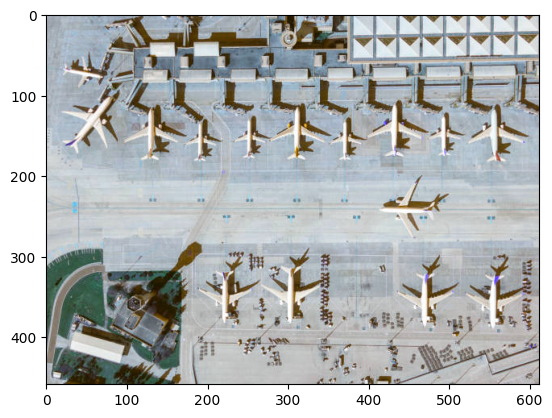

In [10]:
plt.imshow(im)

In [11]:
from detectron2.engine import DefaultPredictor
predictor = DefaultPredictor(cfg)
predictor.model.set_max_net()

#predictor.model.backbone.set_active_subnet([1,1,1,1])
outputs = predictor(im)

/home/akhare39/miniconda3/lib/python3.9/site-packages/fvcore/common/checkpoint.py:252: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f, map_location=torch.

In [12]:
!pwd
#print(predictor.model.backbone.layers)
all_keys = predictor.model.backbone.state_dict().keys()
#print(all_keys)
#print("layers.0.blocks.0.attn.relative_position_bias_table" in all_keys)
#print(predictor.model.backbone.layers[2].downsample)
#print(type(predictor.model.backbone.state_dict()))
#print(predictor.model.backbone.layers[2].blocks[0].attn.relative_position_bias_table.shape)
#'layers.2.blocks.0.attn.qkv.weight'
#print(predictor.model.backbone.layers[2].blocks.state_dict().keys())
#print(predictor.model)

/home/akhare39/animesh/wsobjdet


In [13]:
#torch.save(predictor.model.backbone, "ckpts/COCO_M2F_SWIN_B_InstanceSeg.pt")

In [14]:
#torch.save({"model":predictor.model.backbone.state_dict()}, "ckpts/COCO_M2F_SWIN_B_InstanceSeg_state_dict.pth")

Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)
(550, 734, 3)


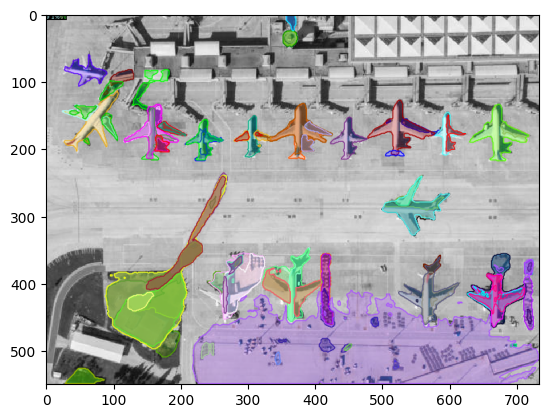

In [15]:
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog
import numpy as np

coco_metadata = MetadataCatalog.get("coco_2017_val_instance")

# Show panoptic/instance/semantic predictions: 
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
instance_result = v.draw_instance_predictions(outputs["instances"].to("cpu")).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()
print("Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)")
print(instance_result.shape)
plt.imshow(instance_result)

In [16]:
#!wget http://images.cocodataset.org/val2017/000000001584.jpg -q -O input.jpg
!wget http://images.cocodataset.org/val2017/000000005477.jpg -q -O input.jpg
im = cv2.imread("./input.jpg")


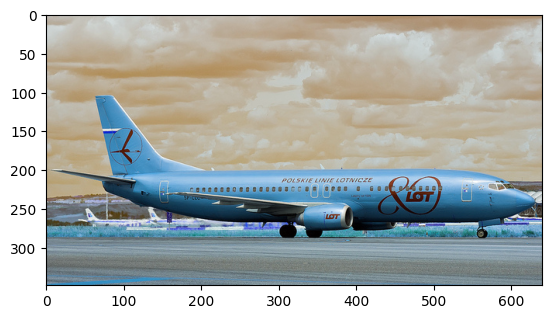

In [17]:
plt.imshow(im)

In [18]:
from detectron2.engine import DefaultPredictor
predictor = DefaultPredictor(cfg)
#predictor.model.backbone.set_active_subnet([0, 1, 3, 0])
outputs = predictor(im)


/home/akhare39/miniconda3/lib/python3.9/site-packages/fvcore/common/checkpoint.py:252: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f, map_location=torch.

In [19]:
#print(outputs)

Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)
(418, 768, 3)


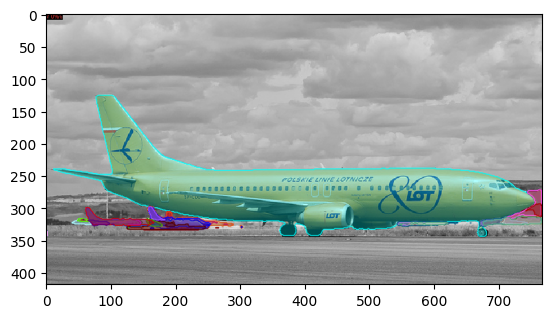

In [20]:
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog
import numpy as np

coco_metadata = MetadataCatalog.get("coco_2017_val_instance")

# Show panoptic/instance/semantic predictions: 
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
instance_result = v.draw_instance_predictions(outputs["instances"].to("cpu")).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()
print("Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)")
print(instance_result.shape)
plt.imshow(instance_result)

In [21]:
trainer = Trainer(cfg)

[11/24 23:38:54 d2.engine.defaults]: Model:
MaskFormer(
  (backbone): ResNet(
    (stem): BasicStem(
      (conv1): Conv2d(
        3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (res2): Sequential(
      (0): BottleneckBlock(
        (shortcut): Conv2d(
          64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv1): Conv2d(
          64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv2): Conv2d(
          64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv3): Conv2d(


[11/24 23:39:09 d2.data.datasets.coco]: Loading datasets/coco/annotations/instances_train2017.json takes 15.18 seconds.
[11/24 23:39:10 d2.data.datasets.coco]: Loaded 118287 images in COCO format from datasets/coco/annotations/instances_train2017.json
[11/24 23:39:16 d2.data.build]: Removed 1021 images with no usable annotations. 117266 images left.
[11/24 23:39:20 d2.data.build]: Distribution of instances among all 80 categories:
|   category    | #instances   |   category   | #instances   |   category    | #instances   |
|:-------------:|:-------------|:------------:|:-------------|:-------------:|:-------------|
|    person     | 257253       |   bicycle    | 7056         |      car      | 43533        |
|  motorcycle   | 8654         |   airplane   | 5129         |      bus      | 6061         |
|     train     | 4570         |    truck     | 9970         |     boat      | 10576        |
| traffic light | 12842        | fire hydrant | 1865         |   stop sign   | 1983         |
|

In [22]:
import os
from detectron2.checkpoint import DetectionCheckpointer

model = Trainer.build_model(cfg)
print(model.backbone.stem.conv1.weight[0, 0, 0, :])
DetectionCheckpointer(model, save_dir=cfg.OUTPUT_DIR).resume_or_load(
    cfg.MODEL.WEIGHTS, resume=True
)
print(model.backbone.stem.conv1.weight[0, 0, 0, :])

[11/24 23:39:25 d2.engine.defaults]: Model:
MaskFormer(
  (backbone): ResNet(
    (stem): BasicStem(
      (conv1): Conv2d(
        3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (res2): Sequential(
      (0): BottleneckBlock(
        (shortcut): Conv2d(
          64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv1): Conv2d(
          64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv2): Conv2d(
          64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv3): Conv2d(


tensor([-0.0073,  0.0133, -0.0164, -0.0032,  0.0214,  0.0107, -0.0398],
       device='cuda:2', grad_fn=<SliceBackward0>)
[11/24 23:39:25 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./elasticdepthresnet_ckpt.pth ...


/home/akhare39/miniconda3/lib/python3.9/site-packages/fvcore/common/checkpoint.py:252: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f, map_location=torch.

tensor([ 0.0110,  0.0112, -0.0148, -0.0208, -0.0340, -0.0341, -0.0556],
       device='cuda:2', grad_fn=<SliceBackward0>)


In [23]:
#print(model.backbone.stem.conv1.norm.weight)

In [24]:
import copy
import torch.nn.functional as F
import torch.nn as nn
import random
import torch


class AverageMeter(object):
    """
    Computes and stores the average and current value
    Copied from: https://github.com/pytorch/examples/blob/master/imagenet/main.py
    """

    def __init__(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

#both group norm and batch norm updated
def set_running_statistics(model, data_loader):
    bn_mean = {}
    bn_var = {}

    gn_mean = {}
    gn_var = {}
    
    forward_model = copy.deepcopy(model)
    for name, m in forward_model.named_modules():
        if isinstance(m, nn.BatchNorm2d):
            bn_mean[name] = AverageMeter()
            bn_var[name] = AverageMeter()

            def new_forward(bn, mean_est, var_est):
                def lambda_forward(x):
                    batch_mean = (
                        x.mean(0, keepdim=True)
                        .mean(2, keepdim=True)
                        .mean(3, keepdim=True)
                    )  # 1, C, 1, 1
                    batch_var = (x - batch_mean) * (x - batch_mean)
                    batch_var = (
                        batch_var.mean(0, keepdim=True)
                        .mean(2, keepdim=True)
                        .mean(3, keepdim=True)
                    )

                    batch_mean = torch.squeeze(batch_mean)
                    batch_var = torch.squeeze(batch_var)

                    mean_est.update(batch_mean.data, x.size(0))
                    var_est.update(batch_var.data, x.size(0))

                    # bn forward using calculated mean & var
                    _feature_dim = batch_mean.size(0)
                    return F.batch_norm(
                        x,
                        batch_mean,
                        batch_var,
                        bn.weight[:_feature_dim],
                        bn.bias[:_feature_dim],
                        False,
                        0.0,
                        bn.eps,
                    )

                return lambda_forward

            m.forward = new_forward(m, bn_mean[name], bn_var[name])
    
    if len(bn_mean) == 0:
        # skip if there is no batch normalization layers in the network
        return

    with torch.no_grad():
        count = 1
        #DynamicBatchNorm2d.SET_RUNNING_STATISTICS = True
        for input_images in data_loader:
            forward_model(input_images)
            count+=1
            if count >= 250:
                break
            if count % 50 == 0:
                print(count)
        #DynamicBatchNorm2d.SET_RUNNING_STATISTICS = False

    for name, m in model.named_modules():
        if name in bn_mean and bn_mean[name].count > 0:
            if "backbone" not in name:
                print("reported")
            feature_dim = bn_mean[name].avg.size(0)
            assert isinstance(m, nn.BatchNorm2d)
            m.running_mean.data[:feature_dim].copy_(bn_mean[name].avg)
            m.running_var.data[:feature_dim].copy_(bn_var[name].avg)

In [25]:
def count_parameters(model, check_grad=False):
    count = 0
    for name, parameter in model.named_parameters():
        #print(name)
        if not check_grad or (check_grad and parameter.requires_grad):
            count += parameter.numel()
    return count

In [26]:
total_num_param = count_parameters(model)
print("total params", total_num_param)
          
def maskformertransformer_param_count_helper(name, param, pixel_decoder_depth, transformer_decoder_depth):
    max_pixel_depth = 6+(pixel_decoder_depth-2)-1
    max_transformer_depth = 9+(transformer_decoder_depth-2)-1
    if 'predictor' in name:
        if 'transformer_self_attention_layers' in name or 'transformer_cross_attention_layers' in name \
            or 'transformer_ffn_layers' in name:
            if int(name.split('.')[3]) <= max_transformer_depth:
                #print(name, int(name.split('.')[3]))
                return param.numel()
            else:
                return 0            
    elif 'pixel_decoder.transformer.encoder.layers' in name:
        if int(name.split('.')[5]) <= max_pixel_depth:
            #print(name, int(name.split('.')[5]))
            return param.numel()
        else:
            return 0
    return param.numel()
          
def count_parameters_small(model, pixel_decoder_depth=2, transformer_decoder_depth=2, check_grad=False):
    count = 0
    for name, parameter in model.named_parameters():
        if 'backbone' in name and 'res2' in name:
            if '0' in name and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res3' in name:
            if ('0' in name or '.1.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res4' in name:
            if ('0' in name or '.1.' in name or '.2.' in name or '.3.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res5' in name:
            if '0' in name and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif not check_grad or (check_grad and parameter.requires_grad):
            count += maskformertransformer_param_count_helper(name, parameter, pixel_decoder_depth, \
                transformer_decoder_depth)
    return count

def count_parameters_large(model, pixel_decoder_depth=2, transformer_decoder_depth=2, check_grad=False):
    count = 0
    for name, parameter in model.named_parameters():
        if not check_grad or (check_grad and parameter.requires_grad):
            count += maskformertransformer_param_count_helper(name, parameter, pixel_decoder_depth, \
                transformer_decoder_depth)
    return count

smallest_net_param = count_parameters_small(model, 0, 0)
print("smallest net params:", smallest_net_param)
print("precentage of total:", smallest_net_param/total_num_param)
print("percentage decrease:", (total_num_param-smallest_net_param)/total_num_param)
def count_parameters_middle(model, pixel_decoder_depth=2, transformer_decoder_depth=2, check_grad=False):
    count = 0
    for name, parameter in model.named_parameters():
        if 'backbone' in name and 'res2' in name:
            if ('0' in name or '.1.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res3' in name:
            if ('0' in name or '.1.' in name or '.2.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res4' in name:
            if ('0' in name or '.1.' in name or '.2.' in name or '.3.' in name or '.4.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res5' in name:
            if ('0' in name or '.1.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif not check_grad or (check_grad and parameter.requires_grad):
            count += maskformertransformer_param_count_helper(name, parameter, pixel_decoder_depth, \
                transformer_decoder_depth)
    return count

middle_net_param = count_parameters_middle(model, 1, 1)
print("number of param in middle network:", middle_net_param)

smallest_backbone_param = count_parameters_small(model, 2, 2)
print("smallest backbone net params:", smallest_backbone_param)

middle_backbone_param = count_parameters_middle(model, 2, 2)
print("middle backbone net params:", middle_backbone_param)

smallest_pixel_decoder_max_rest_param = count_parameters_large(model, 0, 2)
print("max backbone, min pixel decoder, max transformer decoder net params:", smallest_pixel_decoder_max_rest_param)

smallest_transformer_decoder_max_rest_param = count_parameters_large(model, 2, 0)
print("max backbone, max pixel decoder, min transformer decoder net params:", smallest_transformer_decoder_max_rest_param)

middle_backbone_min_tf_decoder_param = count_parameters_middle(model, 2, 1)
print("middle backbone, max pixel decoder, min transformer decoder net params:", middle_backbone_min_tf_decoder_param)

total params 44023377
smallest net params: 27541009
precentage of total: 0.6255996444797953
percentage decrease: 0.3744003555202046
number of param in middle network: 35782193
smallest backbone net params: 32162897
middle backbone net params: 38093137
max backbone, min pixel decoder, max transformer decoder net params: 42558993
max backbone, max pixel decoder, min transformer decoder net params: 40865873
middle backbone, max pixel decoder, min transformer decoder net params: 36514385


In [27]:
print(model)

MaskFormer(
  (backbone): ResNet(
    (stem): BasicStem(
      (conv1): Conv2d(
        3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (res2): Sequential(
      (0): BottleneckBlock(
        (shortcut): Conv2d(
          64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv1): Conv2d(
          64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv2): Conv2d(
          64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv3): Conv2d(
          64, 256, kernel_size=(1, 1), strid

In [28]:
#train_data_loader = trainer.build_train_loader(cfg)

In [29]:
print(model.set_max_net())
print(model.backbone.runtime_depth)
print(model.sem_seg_head.pixel_decoder.transformer.encoder.runtime_depth)
print(model.sem_seg_head.predictor.runtime_depth)

#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))

{'backbone': {'depth_list': [2, 2, 2, 2]}, 'pixel_decoder': {'depth_list': [2]}, 'predictor': {'depth_list': [2]}}
{'res2': 0, 'res3': 0, 'res4': 0, 'res5': 0}
0
0
res2 0 3
3 3
res3 0 4
4 4
res4 0 6
6 6
res5 0 3
3 3


In [30]:
import warnings
warnings.filterwarnings('ignore')
print(model.sample_active_subnet())

{'backbone': {'depth_list': [1, 2, 0, 0]}, 'pixel_decoder': {'depth_list': [0]}, 'predictor': {'depth_list': [2]}}


In [31]:
#MAXIMUM NETWORK
print(model.set_max_net())
#set_running_statistics(model, trainer._trainer.data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'backbone': {'depth_list': [2, 2, 2, 2]}, 'pixel_decoder': {'depth_list': [2]}, 'predictor': {'depth_list': [2]}}
res2 0 3
3 3
res3 0 4
4 4
res4 0 6
6 6
res5 0 3
3 3
[11/24 23:39:26 d2.data.datasets.coco]: Loaded 5000 images in COCO format from datasets/coco/annotations/instances_val2017.json
[11/24 23:39:26 d2.data.build]: Distribution of instances among all 80 categories:
|   category    | #instances   |   category   | #instances   |   category    | #instances   |
|:-------------:|:-------------|:------------:|:-------------|:-------------:|:-------------|
|    person     | 10777        |   bicycle    | 314          |      car      | 1918         |
|  motorcycle   | 367          |   airplane   | 143          |      bus      | 283          |
|     train     | 190          |    truck     | 414          |     boat      | 424          |
| traffic light | 634          | fire hydrant | 101          |   stop sign   | 75           |
| parking meter | 60           |    bench     | 411       

[11/24 23:41:32 d2.evaluation.evaluator]: Inference done 690/5000. Dataloading: 0.0031 s/iter. Inference: 0.0910 s/iter. Eval: 0.0859 s/iter. Total: 0.1802 s/iter. ETA=0:12:56
[11/24 23:41:37 d2.evaluation.evaluator]: Inference done 718/5000. Dataloading: 0.0032 s/iter. Inference: 0.0909 s/iter. Eval: 0.0859 s/iter. Total: 0.1801 s/iter. ETA=0:12:51
[11/24 23:41:42 d2.evaluation.evaluator]: Inference done 746/5000. Dataloading: 0.0032 s/iter. Inference: 0.0909 s/iter. Eval: 0.0860 s/iter. Total: 0.1802 s/iter. ETA=0:12:46
[11/24 23:41:47 d2.evaluation.evaluator]: Inference done 774/5000. Dataloading: 0.0031 s/iter. Inference: 0.0909 s/iter. Eval: 0.0860 s/iter. Total: 0.1802 s/iter. ETA=0:12:41
[11/24 23:41:52 d2.evaluation.evaluator]: Inference done 802/5000. Dataloading: 0.0031 s/iter. Inference: 0.0910 s/iter. Eval: 0.0861 s/iter. Total: 0.1804 s/iter. ETA=0:12:37
[11/24 23:41:57 d2.evaluation.evaluator]: Inference done 834/5000. Dataloading: 0.0031 s/iter. Inference: 0.0906 s/iter.

[11/24 23:45:20 d2.evaluation.evaluator]: Inference done 2109/5000. Dataloading: 0.0029 s/iter. Inference: 0.0849 s/iter. Eval: 0.0794 s/iter. Total: 0.1674 s/iter. ETA=0:08:03
[11/24 23:45:25 d2.evaluation.evaluator]: Inference done 2145/5000. Dataloading: 0.0029 s/iter. Inference: 0.0847 s/iter. Eval: 0.0791 s/iter. Total: 0.1669 s/iter. ETA=0:07:56
[11/24 23:45:30 d2.evaluation.evaluator]: Inference done 2179/5000. Dataloading: 0.0029 s/iter. Inference: 0.0846 s/iter. Eval: 0.0790 s/iter. Total: 0.1666 s/iter. ETA=0:07:50
[11/24 23:45:35 d2.evaluation.evaluator]: Inference done 2215/5000. Dataloading: 0.0029 s/iter. Inference: 0.0844 s/iter. Eval: 0.0788 s/iter. Total: 0.1662 s/iter. ETA=0:07:42
[11/24 23:45:40 d2.evaluation.evaluator]: Inference done 2250/5000. Dataloading: 0.0029 s/iter. Inference: 0.0843 s/iter. Eval: 0.0785 s/iter. Total: 0.1658 s/iter. ETA=0:07:36
[11/24 23:45:46 d2.evaluation.evaluator]: Inference done 2286/5000. Dataloading: 0.0029 s/iter. Inference: 0.0842 s

[11/24 23:49:09 d2.evaluation.evaluator]: Inference done 3723/5000. Dataloading: 0.0024 s/iter. Inference: 0.0806 s/iter. Eval: 0.0731 s/iter. Total: 0.1562 s/iter. ETA=0:03:19
[11/24 23:49:14 d2.evaluation.evaluator]: Inference done 3765/5000. Dataloading: 0.0024 s/iter. Inference: 0.0805 s/iter. Eval: 0.0728 s/iter. Total: 0.1558 s/iter. ETA=0:03:12
[11/24 23:49:19 d2.evaluation.evaluator]: Inference done 3806/5000. Dataloading: 0.0023 s/iter. Inference: 0.0804 s/iter. Eval: 0.0726 s/iter. Total: 0.1554 s/iter. ETA=0:03:05
[11/24 23:49:24 d2.evaluation.evaluator]: Inference done 3847/5000. Dataloading: 0.0023 s/iter. Inference: 0.0803 s/iter. Eval: 0.0724 s/iter. Total: 0.1551 s/iter. ETA=0:02:58
[11/24 23:49:29 d2.evaluation.evaluator]: Inference done 3889/5000. Dataloading: 0.0023 s/iter. Inference: 0.0802 s/iter. Eval: 0.0721 s/iter. Total: 0.1547 s/iter. ETA=0:02:51
[11/24 23:49:34 d2.evaluation.evaluator]: Inference done 3929/5000. Dataloading: 0.0023 s/iter. Inference: 0.0801 s

[11/24 23:52:18 d2.evaluation.coco_evaluation]: Per-category bbox AP: 
| category      | AP    | category     | AP    | category       | AP    |
|:--------------|:------|:-------------|:------|:---------------|:------|
| person        | 0.000 | bicycle      | 0.000 | car            | 0.000 |
| motorcycle    | 0.000 | airplane     | 0.000 | bus            | 0.000 |
| train         | 0.000 | truck        | 0.000 | boat           | 0.000 |
| traffic light | 0.000 | fire hydrant | 0.000 | stop sign      | 0.000 |
| parking meter | 0.000 | bench        | 0.000 | bird           | 0.000 |
| cat           | 0.000 | dog          | 0.000 | horse          | 0.000 |
| sheep         | 0.000 | cow          | 0.000 | elephant       | 0.000 |
| bear          | 0.000 | zebra        | 0.000 | giraffe        | 0.000 |
| backpack      | 0.000 | umbrella     | 0.000 | handbag        | 0.000 |
| tie           | 0.000 | suitcase     | 0.000 | frisbee        | 0.000 |
| skis          | 0.000 | snowboard    | 

In [32]:
#Smallest NETWORK
import warnings
warnings.filterwarnings('ignore')
model.set_max_net()
model.backbone.set_active_subnet(depth_list=[0, 0, 0, 0])
model.sem_seg_head.pixel_decoder.transformer.set_active_subnet(depth_list=[0])
model.sem_seg_head.predictor.set_active_subnet(depth_list=[0])
minnet_arch = {
    'pixel_decoder': {'depth_list': [0]},
    'predictor': {'depth_list': [0]}
}
#model.set_active_subnet(*minnet_arch)
print(model.backbone.runtime_depth)
print("pixel decoder depth", model.sem_seg_head.pixel_decoder.transformer.encoder.runtime_depth)
print("transformer decoder depth", model.sem_seg_head.predictor.runtime_depth)

#set_running_statistics(model, trainer._trainer.data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 2, 'res3': 2, 'res4': 2, 'res5': 2}
pixel decoder depth 2
transformer decoder depth 2
res2 2 1
3 1
res3 2 2
4 2
res4 2 4
6 4
res5 2 1
3 1
[11/24 23:52:43 d2.data.datasets.coco]: Loaded 5000 images in COCO format from datasets/coco/annotations/instances_val2017.json
[11/24 23:52:43 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[11/24 23:52:43 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[11/24 23:52:43 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[11/24 23:52:43 d2.data.common]: Serialized dataset takes 19.10 MiB
[11/24 23:52:44 d2.evaluation.evaluator]: Start inference on 5000 batches
[11/24 23:52:46 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0009 s/iter. Inference: 0.0527 s/iter. Eval: 0.0669 s/iter. Total: 0.1206 s/iter. ETA=0:10:01
[11/2

[11/24 23:56:08 d2.evaluation.evaluator]: Inference done 1611/5000. Dataloading: 0.0018 s/iter. Inference: 0.0550 s/iter. Eval: 0.0696 s/iter. Total: 0.1264 s/iter. ETA=0:07:08
[11/24 23:56:13 d2.evaluation.evaluator]: Inference done 1651/5000. Dataloading: 0.0017 s/iter. Inference: 0.0550 s/iter. Eval: 0.0696 s/iter. Total: 0.1264 s/iter. ETA=0:07:03
[11/24 23:56:18 d2.evaluation.evaluator]: Inference done 1690/5000. Dataloading: 0.0018 s/iter. Inference: 0.0551 s/iter. Eval: 0.0695 s/iter. Total: 0.1265 s/iter. ETA=0:06:58
[11/24 23:56:23 d2.evaluation.evaluator]: Inference done 1730/5000. Dataloading: 0.0018 s/iter. Inference: 0.0551 s/iter. Eval: 0.0695 s/iter. Total: 0.1265 s/iter. ETA=0:06:53
[11/24 23:56:28 d2.evaluation.evaluator]: Inference done 1770/5000. Dataloading: 0.0018 s/iter. Inference: 0.0551 s/iter. Eval: 0.0695 s/iter. Total: 0.1265 s/iter. ETA=0:06:48
[11/24 23:56:33 d2.evaluation.evaluator]: Inference done 1808/5000. Dataloading: 0.0018 s/iter. Inference: 0.0551 s

[11/24 23:59:56 d2.evaluation.evaluator]: Inference done 3442/5000. Dataloading: 0.0018 s/iter. Inference: 0.0551 s/iter. Eval: 0.0683 s/iter. Total: 0.1253 s/iter. ETA=0:03:15
[11/25 00:00:01 d2.evaluation.evaluator]: Inference done 3482/5000. Dataloading: 0.0018 s/iter. Inference: 0.0551 s/iter. Eval: 0.0683 s/iter. Total: 0.1253 s/iter. ETA=0:03:10
[11/25 00:00:06 d2.evaluation.evaluator]: Inference done 3524/5000. Dataloading: 0.0018 s/iter. Inference: 0.0551 s/iter. Eval: 0.0683 s/iter. Total: 0.1253 s/iter. ETA=0:03:04
[11/25 00:00:11 d2.evaluation.evaluator]: Inference done 3564/5000. Dataloading: 0.0018 s/iter. Inference: 0.0551 s/iter. Eval: 0.0683 s/iter. Total: 0.1253 s/iter. ETA=0:02:59
[11/25 00:00:16 d2.evaluation.evaluator]: Inference done 3603/5000. Dataloading: 0.0018 s/iter. Inference: 0.0551 s/iter. Eval: 0.0683 s/iter. Total: 0.1253 s/iter. ETA=0:02:55
[11/25 00:00:21 d2.evaluation.evaluator]: Inference done 3642/5000. Dataloading: 0.0018 s/iter. Inference: 0.0551 s

[11/25 00:03:27 d2.evaluation.coco_evaluation]: Per-category bbox AP: 
| category      | AP    | category     | AP    | category       | AP    |
|:--------------|:------|:-------------|:------|:---------------|:------|
| person        | 0.000 | bicycle      | 0.000 | car            | 0.000 |
| motorcycle    | 0.000 | airplane     | 0.000 | bus            | 0.000 |
| train         | 0.000 | truck        | 0.000 | boat           | 0.000 |
| traffic light | 0.000 | fire hydrant | 0.000 | stop sign      | 0.000 |
| parking meter | 0.000 | bench        | 0.000 | bird           | 0.000 |
| cat           | 0.000 | dog          | 0.000 | horse          | 0.000 |
| sheep         | 0.000 | cow          | 0.000 | elephant       | 0.000 |
| bear          | 0.000 | zebra        | 0.000 | giraffe        | 0.000 |
| backpack      | 0.000 | umbrella     | 0.000 | handbag        | 0.000 |
| tie           | 0.000 | suitcase     | 0.000 | frisbee        | 0.000 |
| skis          | 0.000 | snowboard    | 

In [33]:
#Smallest NETWORK RESNET 50 BACKBONE max everything else
import warnings
warnings.filterwarnings('ignore')
model.set_max_net()
model.backbone.set_active_subnet(depth_list=[0, 0, 0, 0])
#model.sem_seg_head.pixel_decoder.transformer.set_active_subnet(depth_list=[0])
#model.sem_seg_head.predictor.set_active_subnet(depth_list=[0])
#minnet_arch = {
#    'pixel_decoder': {'depth_list': [0]},
#    'predictor': {'depth_list': [0]}
#}
#model.set_active_subnet(*minnet_arch)
print(model.backbone.runtime_depth)
print("pixel decoder depth", model.sem_seg_head.pixel_decoder.transformer.encoder.runtime_depth)
print("transformer decoder depth", model.sem_seg_head.predictor.runtime_depth)

#set_running_statistics(model, trainer._trainer.data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 2, 'res3': 2, 'res4': 2, 'res5': 2}
pixel decoder depth 0
transformer decoder depth 0
res2 2 1
3 1
res3 2 2
4 2
res4 2 4
6 4
res5 2 1
3 1
[11/25 00:03:59 d2.data.datasets.coco]: Loaded 5000 images in COCO format from datasets/coco/annotations/instances_val2017.json
[11/25 00:04:00 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[11/25 00:04:00 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[11/25 00:04:00 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[11/25 00:04:00 d2.data.common]: Serialized dataset takes 19.10 MiB
[11/25 00:04:00 d2.evaluation.evaluator]: Start inference on 5000 batches
[11/25 00:04:02 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0013 s/iter. Inference: 0.0672 s/iter. Eval: 0.0806 s/iter. Total: 0.1490 s/iter. ETA=0:12:23
[11/2

[11/25 00:07:25 d2.evaluation.evaluator]: Inference done 1484/5000. Dataloading: 0.0023 s/iter. Inference: 0.0689 s/iter. Eval: 0.0663 s/iter. Total: 0.1375 s/iter. ETA=0:08:03
[11/25 00:07:30 d2.evaluation.evaluator]: Inference done 1520/5000. Dataloading: 0.0022 s/iter. Inference: 0.0688 s/iter. Eval: 0.0664 s/iter. Total: 0.1376 s/iter. ETA=0:07:58
[11/25 00:07:35 d2.evaluation.evaluator]: Inference done 1556/5000. Dataloading: 0.0022 s/iter. Inference: 0.0688 s/iter. Eval: 0.0665 s/iter. Total: 0.1377 s/iter. ETA=0:07:54
[11/25 00:07:40 d2.evaluation.evaluator]: Inference done 1595/5000. Dataloading: 0.0022 s/iter. Inference: 0.0688 s/iter. Eval: 0.0664 s/iter. Total: 0.1374 s/iter. ETA=0:07:47
[11/25 00:07:45 d2.evaluation.evaluator]: Inference done 1632/5000. Dataloading: 0.0022 s/iter. Inference: 0.0687 s/iter. Eval: 0.0663 s/iter. Total: 0.1374 s/iter. ETA=0:07:42
[11/25 00:07:50 d2.evaluation.evaluator]: Inference done 1670/5000. Dataloading: 0.0022 s/iter. Inference: 0.0687 s

[11/25 00:11:13 d2.evaluation.evaluator]: Inference done 3158/5000. Dataloading: 0.0022 s/iter. Inference: 0.0688 s/iter. Eval: 0.0659 s/iter. Total: 0.1370 s/iter. ETA=0:04:12
[11/25 00:11:18 d2.evaluation.evaluator]: Inference done 3196/5000. Dataloading: 0.0022 s/iter. Inference: 0.0688 s/iter. Eval: 0.0658 s/iter. Total: 0.1369 s/iter. ETA=0:04:07
[11/25 00:11:24 d2.evaluation.evaluator]: Inference done 3234/5000. Dataloading: 0.0022 s/iter. Inference: 0.0688 s/iter. Eval: 0.0658 s/iter. Total: 0.1369 s/iter. ETA=0:04:01
[11/25 00:11:29 d2.evaluation.evaluator]: Inference done 3272/5000. Dataloading: 0.0022 s/iter. Inference: 0.0688 s/iter. Eval: 0.0658 s/iter. Total: 0.1369 s/iter. ETA=0:03:56
[11/25 00:11:34 d2.evaluation.evaluator]: Inference done 3310/5000. Dataloading: 0.0022 s/iter. Inference: 0.0688 s/iter. Eval: 0.0658 s/iter. Total: 0.1369 s/iter. ETA=0:03:51
[11/25 00:11:39 d2.evaluation.evaluator]: Inference done 3347/5000. Dataloading: 0.0022 s/iter. Inference: 0.0688 s

[11/25 00:15:01 d2.evaluation.evaluator]: Inference done 4849/5000. Dataloading: 0.0021 s/iter. Inference: 0.0688 s/iter. Eval: 0.0652 s/iter. Total: 0.1363 s/iter. ETA=0:00:20
[11/25 00:15:06 d2.evaluation.evaluator]: Inference done 4890/5000. Dataloading: 0.0021 s/iter. Inference: 0.0688 s/iter. Eval: 0.0651 s/iter. Total: 0.1361 s/iter. ETA=0:00:14
[11/25 00:15:12 d2.evaluation.evaluator]: Inference done 4932/5000. Dataloading: 0.0021 s/iter. Inference: 0.0688 s/iter. Eval: 0.0650 s/iter. Total: 0.1360 s/iter. ETA=0:00:09
[11/25 00:15:17 d2.evaluation.evaluator]: Inference done 4973/5000. Dataloading: 0.0021 s/iter. Inference: 0.0688 s/iter. Eval: 0.0649 s/iter. Total: 0.1359 s/iter. ETA=0:00:03
[11/25 00:15:20 d2.evaluation.evaluator]: Total inference time: 0:11:18.690820 (0.135874 s / iter per device, on 1 devices)
[11/25 00:15:20 d2.evaluation.evaluator]: Total inference pure compute time: 0:05:43 (0.068778 s / iter per device, on 1 devices)
[11/25 00:15:24 d2.evaluation.coco_eva

[11/25 00:15:58 d2.engine.defaults]: Evaluation results for coco_2017_val in csv format:
[11/25 00:15:58 d2.evaluation.testing]: copypaste: Task: bbox
[11/25 00:15:58 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[11/25 00:15:58 d2.evaluation.testing]: copypaste: 0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
[11/25 00:15:58 d2.evaluation.testing]: copypaste: Task: segm
[11/25 00:15:58 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[11/25 00:15:58 d2.evaluation.testing]: copypaste: 34.9118,54.3376,37.0841,15.7240,37.5160,53.7033
OrderedDict([('bbox', {'AP': 0.0, 'AP50': 0.0, 'AP75': 0.0, 'APs': 0.0, 'APm': 0.0, 'APl': 0.0, 'AP-person': 0.0, 'AP-bicycle': 0.0, 'AP-car': 0.0, 'AP-motorcycle': 0.0, 'AP-airplane': 0.0, 'AP-bus': 0.0, 'AP-train': 0.0, 'AP-truck': 0.0, 'AP-boat': 0.0, 'AP-traffic light': 0.0, 'AP-fire hydrant': 0.0, 'AP-stop sign': 0.0, 'AP-parking meter': 0.0, 'AP-bench': 0.0, 'AP-bird': 0.0, 'AP-cat': 0.0, 'AP-dog': 0.0, 'AP-horse': 0.0, 'AP-sheep': 0

In [34]:
#Test max backbone, max transformer decoder, min pixel decoder
model.backbone.set_max_net()
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_max_net()
model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([0])
print(model.sem_seg_head.pixel_decoder.transformer.encoder.runtime_depth)
#set_running_statistics(model, trainer._trainer.data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 0, 'res3': 0, 'res4': 0, 'res5': 0}
2
res2 0 3
3 3
res3 0 4
4 4
res4 0 6
6 6
res5 0 3
3 3
[11/25 00:15:58 d2.data.datasets.coco]: Loaded 5000 images in COCO format from datasets/coco/annotations/instances_val2017.json
[11/25 00:15:59 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[11/25 00:15:59 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[11/25 00:15:59 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[11/25 00:15:59 d2.data.common]: Serialized dataset takes 19.10 MiB
[11/25 00:15:59 d2.evaluation.evaluator]: Start inference on 5000 batches
[11/25 00:16:01 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0009 s/iter. Inference: 0.0640 s/iter. Eval: 0.0639 s/iter. Total: 0.1288 s/iter. ETA=0:10:42
[11/25 00:16:06 d2.evaluation.evaluator]: Inference d

[11/25 00:19:24 d2.evaluation.evaluator]: Inference done 1491/5000. Dataloading: 0.0020 s/iter. Inference: 0.0674 s/iter. Eval: 0.0675 s/iter. Total: 0.1369 s/iter. ETA=0:08:00
[11/25 00:19:29 d2.evaluation.evaluator]: Inference done 1530/5000. Dataloading: 0.0020 s/iter. Inference: 0.0673 s/iter. Eval: 0.0674 s/iter. Total: 0.1368 s/iter. ETA=0:07:54
[11/25 00:19:34 d2.evaluation.evaluator]: Inference done 1569/5000. Dataloading: 0.0020 s/iter. Inference: 0.0673 s/iter. Eval: 0.0672 s/iter. Total: 0.1366 s/iter. ETA=0:07:48
[11/25 00:19:39 d2.evaluation.evaluator]: Inference done 1606/5000. Dataloading: 0.0020 s/iter. Inference: 0.0673 s/iter. Eval: 0.0672 s/iter. Total: 0.1366 s/iter. ETA=0:07:43
[11/25 00:19:44 d2.evaluation.evaluator]: Inference done 1643/5000. Dataloading: 0.0020 s/iter. Inference: 0.0672 s/iter. Eval: 0.0672 s/iter. Total: 0.1366 s/iter. ETA=0:07:38
[11/25 00:19:49 d2.evaluation.evaluator]: Inference done 1680/5000. Dataloading: 0.0020 s/iter. Inference: 0.0673 s

[11/25 00:23:13 d2.evaluation.evaluator]: Inference done 3176/5000. Dataloading: 0.0020 s/iter. Inference: 0.0674 s/iter. Eval: 0.0668 s/iter. Total: 0.1363 s/iter. ETA=0:04:08
[11/25 00:23:18 d2.evaluation.evaluator]: Inference done 3213/5000. Dataloading: 0.0020 s/iter. Inference: 0.0674 s/iter. Eval: 0.0668 s/iter. Total: 0.1363 s/iter. ETA=0:04:03
[11/25 00:23:23 d2.evaluation.evaluator]: Inference done 3251/5000. Dataloading: 0.0020 s/iter. Inference: 0.0674 s/iter. Eval: 0.0668 s/iter. Total: 0.1363 s/iter. ETA=0:03:58
[11/25 00:23:28 d2.evaluation.evaluator]: Inference done 3290/5000. Dataloading: 0.0020 s/iter. Inference: 0.0674 s/iter. Eval: 0.0668 s/iter. Total: 0.1362 s/iter. ETA=0:03:52
[11/25 00:23:33 d2.evaluation.evaluator]: Inference done 3327/5000. Dataloading: 0.0020 s/iter. Inference: 0.0674 s/iter. Eval: 0.0668 s/iter. Total: 0.1363 s/iter. ETA=0:03:47
[11/25 00:23:38 d2.evaluation.evaluator]: Inference done 3366/5000. Dataloading: 0.0020 s/iter. Inference: 0.0674 s

[11/25 00:27:01 d2.evaluation.evaluator]: Inference done 4858/5000. Dataloading: 0.0020 s/iter. Inference: 0.0677 s/iter. Eval: 0.0665 s/iter. Total: 0.1362 s/iter. ETA=0:00:19
[11/25 00:27:06 d2.evaluation.evaluator]: Inference done 4899/5000. Dataloading: 0.0020 s/iter. Inference: 0.0676 s/iter. Eval: 0.0664 s/iter. Total: 0.1361 s/iter. ETA=0:00:13
[11/25 00:27:11 d2.evaluation.evaluator]: Inference done 4936/5000. Dataloading: 0.0020 s/iter. Inference: 0.0676 s/iter. Eval: 0.0664 s/iter. Total: 0.1361 s/iter. ETA=0:00:08
[11/25 00:27:16 d2.evaluation.evaluator]: Inference done 4973/5000. Dataloading: 0.0020 s/iter. Inference: 0.0677 s/iter. Eval: 0.0664 s/iter. Total: 0.1361 s/iter. ETA=0:00:03
[11/25 00:27:20 d2.evaluation.evaluator]: Total inference time: 0:11:19.897335 (0.136116 s / iter per device, on 1 devices)
[11/25 00:27:20 d2.evaluation.evaluator]: Total inference pure compute time: 0:05:37 (0.067639 s / iter per device, on 1 devices)
[11/25 00:27:26 d2.evaluation.coco_eva

[11/25 00:28:09 d2.engine.defaults]: Evaluation results for coco_2017_val in csv format:
[11/25 00:28:09 d2.evaluation.testing]: copypaste: Task: bbox
[11/25 00:28:09 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[11/25 00:28:09 d2.evaluation.testing]: copypaste: 0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
[11/25 00:28:09 d2.evaluation.testing]: copypaste: Task: segm
[11/25 00:28:09 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[11/25 00:28:09 d2.evaluation.testing]: copypaste: 3.2144,8.6549,1.9502,1.0771,3.7510,5.5621
OrderedDict([('bbox', {'AP': 0.0, 'AP50': 0.0, 'AP75': 0.0, 'APs': 0.0, 'APm': 0.0, 'APl': 0.0, 'AP-person': 0.0, 'AP-bicycle': 0.0, 'AP-car': 0.0, 'AP-motorcycle': 0.0, 'AP-airplane': 0.0, 'AP-bus': 0.0, 'AP-train': 0.0, 'AP-truck': 0.0, 'AP-boat': 0.0, 'AP-traffic light': 0.0, 'AP-fire hydrant': 0.0, 'AP-stop sign': 0.0, 'AP-parking meter': 0.0, 'AP-bench': 0.0, 'AP-bird': 0.0, 'AP-cat': 0.0, 'AP-dog': 0.0, 'AP-horse': 0.0, 'AP-sheep': 0.0, 'A

In [35]:
#Test max backbone, min transformer decoder, max pixel decoder
model.backbone.set_max_net()
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_active_subnet([0])
model.sem_seg_head.pixel_decoder.transformer.set_max_net()
print(model.sem_seg_head.predictor.runtime_depth)
#set_running_statistics(model, trainer._trainer.data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 0, 'res3': 0, 'res4': 0, 'res5': 0}
2
res2 0 3
3 3
res3 0 4
4 4
res4 0 6
6 6
res5 0 3
3 3
[11/25 00:28:10 d2.data.datasets.coco]: Loaded 5000 images in COCO format from datasets/coco/annotations/instances_val2017.json
[11/25 00:28:10 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[11/25 00:28:10 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[11/25 00:28:10 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[11/25 00:28:10 d2.data.common]: Serialized dataset takes 19.10 MiB
[11/25 00:28:10 d2.evaluation.evaluator]: Start inference on 5000 batches
[11/25 00:28:13 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0035 s/iter. Inference: 0.0672 s/iter. Eval: 0.0826 s/iter. Total: 0.1533 s/iter. ETA=0:12:45
[11/25 00:28:18 d2.evaluation.evaluator]: Inference d

[11/25 00:31:36 d2.evaluation.evaluator]: Inference done 1478/5000. Dataloading: 0.0022 s/iter. Inference: 0.0683 s/iter. Eval: 0.0678 s/iter. Total: 0.1384 s/iter. ETA=0:08:07
[11/25 00:31:41 d2.evaluation.evaluator]: Inference done 1516/5000. Dataloading: 0.0022 s/iter. Inference: 0.0683 s/iter. Eval: 0.0677 s/iter. Total: 0.1382 s/iter. ETA=0:08:01
[11/25 00:31:46 d2.evaluation.evaluator]: Inference done 1553/5000. Dataloading: 0.0022 s/iter. Inference: 0.0683 s/iter. Eval: 0.0676 s/iter. Total: 0.1382 s/iter. ETA=0:07:56
[11/25 00:31:51 d2.evaluation.evaluator]: Inference done 1590/5000. Dataloading: 0.0022 s/iter. Inference: 0.0683 s/iter. Eval: 0.0675 s/iter. Total: 0.1382 s/iter. ETA=0:07:51
[11/25 00:31:56 d2.evaluation.evaluator]: Inference done 1626/5000. Dataloading: 0.0022 s/iter. Inference: 0.0683 s/iter. Eval: 0.0676 s/iter. Total: 0.1382 s/iter. ETA=0:07:46
[11/25 00:32:01 d2.evaluation.evaluator]: Inference done 1664/5000. Dataloading: 0.0021 s/iter. Inference: 0.0683 s

[11/25 00:35:24 d2.evaluation.evaluator]: Inference done 3141/5000. Dataloading: 0.0021 s/iter. Inference: 0.0684 s/iter. Eval: 0.0672 s/iter. Total: 0.1378 s/iter. ETA=0:04:16
[11/25 00:35:29 d2.evaluation.evaluator]: Inference done 3178/5000. Dataloading: 0.0021 s/iter. Inference: 0.0684 s/iter. Eval: 0.0672 s/iter. Total: 0.1378 s/iter. ETA=0:04:11
[11/25 00:35:34 d2.evaluation.evaluator]: Inference done 3215/5000. Dataloading: 0.0021 s/iter. Inference: 0.0685 s/iter. Eval: 0.0671 s/iter. Total: 0.1377 s/iter. ETA=0:04:05
[11/25 00:35:39 d2.evaluation.evaluator]: Inference done 3252/5000. Dataloading: 0.0021 s/iter. Inference: 0.0684 s/iter. Eval: 0.0671 s/iter. Total: 0.1377 s/iter. ETA=0:04:00
[11/25 00:35:44 d2.evaluation.evaluator]: Inference done 3289/5000. Dataloading: 0.0021 s/iter. Inference: 0.0684 s/iter. Eval: 0.0671 s/iter. Total: 0.1377 s/iter. ETA=0:03:55
[11/25 00:35:49 d2.evaluation.evaluator]: Inference done 3327/5000. Dataloading: 0.0021 s/iter. Inference: 0.0684 s

[11/25 00:39:12 d2.evaluation.evaluator]: Inference done 4813/5000. Dataloading: 0.0021 s/iter. Inference: 0.0686 s/iter. Eval: 0.0665 s/iter. Total: 0.1373 s/iter. ETA=0:00:25
[11/25 00:39:17 d2.evaluation.evaluator]: Inference done 4850/5000. Dataloading: 0.0021 s/iter. Inference: 0.0686 s/iter. Eval: 0.0665 s/iter. Total: 0.1373 s/iter. ETA=0:00:20
[11/25 00:39:22 d2.evaluation.evaluator]: Inference done 4889/5000. Dataloading: 0.0021 s/iter. Inference: 0.0686 s/iter. Eval: 0.0665 s/iter. Total: 0.1372 s/iter. ETA=0:00:15
[11/25 00:39:27 d2.evaluation.evaluator]: Inference done 4925/5000. Dataloading: 0.0021 s/iter. Inference: 0.0686 s/iter. Eval: 0.0665 s/iter. Total: 0.1372 s/iter. ETA=0:00:10
[11/25 00:39:32 d2.evaluation.evaluator]: Inference done 4962/5000. Dataloading: 0.0021 s/iter. Inference: 0.0686 s/iter. Eval: 0.0665 s/iter. Total: 0.1372 s/iter. ETA=0:00:05
[11/25 00:39:37 d2.evaluation.evaluator]: Inference done 4999/5000. Dataloading: 0.0021 s/iter. Inference: 0.0686 s

[11/25 00:40:15 d2.engine.defaults]: Evaluation results for coco_2017_val in csv format:
[11/25 00:40:15 d2.evaluation.testing]: copypaste: Task: bbox
[11/25 00:40:15 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[11/25 00:40:15 d2.evaluation.testing]: copypaste: 0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
[11/25 00:40:15 d2.evaluation.testing]: copypaste: Task: segm
[11/25 00:40:15 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[11/25 00:40:15 d2.evaluation.testing]: copypaste: 41.8278,63.4715,44.9509,21.5252,45.0289,62.9821
OrderedDict([('bbox', {'AP': 0.0, 'AP50': 0.0, 'AP75': 0.0, 'APs': 0.0, 'APm': 0.0, 'APl': 0.0, 'AP-person': 0.0, 'AP-bicycle': 0.0, 'AP-car': 0.0, 'AP-motorcycle': 0.0, 'AP-airplane': 0.0, 'AP-bus': 0.0, 'AP-train': 0.0, 'AP-truck': 0.0, 'AP-boat': 0.0, 'AP-traffic light': 0.0, 'AP-fire hydrant': 0.0, 'AP-stop sign': 0.0, 'AP-parking meter': 0.0, 'AP-bench': 0.0, 'AP-bird': 0.0, 'AP-cat': 0.0, 'AP-dog': 0.0, 'AP-horse': 0.0, 'AP-sheep': 0

In [36]:
#Test middle network
model.backbone.set_active_subnet(depth_list=[1, 1, 1, 1])
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_active_subnet([1])
print(model.sem_seg_head.predictor.runtime_depth)
model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([1])

#set_running_statistics(model, trainer._trainer.data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 1, 'res3': 1, 'res4': 1, 'res5': 1}
1
res2 1 2
3 2
res3 1 3
4 3
res4 1 5
6 5
res5 1 2
3 2
[11/25 00:40:16 d2.data.datasets.coco]: Loaded 5000 images in COCO format from datasets/coco/annotations/instances_val2017.json
[11/25 00:40:16 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[11/25 00:40:16 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[11/25 00:40:16 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[11/25 00:40:16 d2.data.common]: Serialized dataset takes 19.10 MiB
[11/25 00:40:17 d2.evaluation.evaluator]: Start inference on 5000 batches
[11/25 00:40:19 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0010 s/iter. Inference: 0.0630 s/iter. Eval: 0.0962 s/iter. Total: 0.1603 s/iter. ETA=0:13:19
[11/25 00:40:24 d2.evaluation.evaluator]: Inference d

[11/25 00:43:42 d2.evaluation.evaluator]: Inference done 1576/5000. Dataloading: 0.0021 s/iter. Inference: 0.0629 s/iter. Eval: 0.0644 s/iter. Total: 0.1294 s/iter. ETA=0:07:23
[11/25 00:43:47 d2.evaluation.evaluator]: Inference done 1617/5000. Dataloading: 0.0021 s/iter. Inference: 0.0628 s/iter. Eval: 0.0643 s/iter. Total: 0.1293 s/iter. ETA=0:07:17
[11/25 00:43:52 d2.evaluation.evaluator]: Inference done 1657/5000. Dataloading: 0.0021 s/iter. Inference: 0.0628 s/iter. Eval: 0.0643 s/iter. Total: 0.1292 s/iter. ETA=0:07:12
[11/25 00:43:57 d2.evaluation.evaluator]: Inference done 1696/5000. Dataloading: 0.0020 s/iter. Inference: 0.0628 s/iter. Eval: 0.0644 s/iter. Total: 0.1293 s/iter. ETA=0:07:07
[11/25 00:44:02 d2.evaluation.evaluator]: Inference done 1737/5000. Dataloading: 0.0020 s/iter. Inference: 0.0627 s/iter. Eval: 0.0643 s/iter. Total: 0.1291 s/iter. ETA=0:07:01
[11/25 00:44:07 d2.evaluation.evaluator]: Inference done 1781/5000. Dataloading: 0.0020 s/iter. Inference: 0.0626 s

[11/25 00:47:29 d2.evaluation.evaluator]: Inference done 3272/5000. Dataloading: 0.0021 s/iter. Inference: 0.0639 s/iter. Eval: 0.0659 s/iter. Total: 0.1320 s/iter. ETA=0:03:48
[11/25 00:47:34 d2.evaluation.evaluator]: Inference done 3307/5000. Dataloading: 0.0021 s/iter. Inference: 0.0639 s/iter. Eval: 0.0659 s/iter. Total: 0.1321 s/iter. ETA=0:03:43
[11/25 00:47:39 d2.evaluation.evaluator]: Inference done 3342/5000. Dataloading: 0.0021 s/iter. Inference: 0.0640 s/iter. Eval: 0.0660 s/iter. Total: 0.1322 s/iter. ETA=0:03:39
[11/25 00:47:45 d2.evaluation.evaluator]: Inference done 3375/5000. Dataloading: 0.0021 s/iter. Inference: 0.0641 s/iter. Eval: 0.0661 s/iter. Total: 0.1324 s/iter. ETA=0:03:35
[11/25 00:47:50 d2.evaluation.evaluator]: Inference done 3411/5000. Dataloading: 0.0021 s/iter. Inference: 0.0641 s/iter. Eval: 0.0662 s/iter. Total: 0.1325 s/iter. ETA=0:03:30
[11/25 00:47:55 d2.evaluation.evaluator]: Inference done 3447/5000. Dataloading: 0.0022 s/iter. Inference: 0.0641 s

[11/25 00:51:18 d2.evaluation.evaluator]: Inference done 4816/5000. Dataloading: 0.0025 s/iter. Inference: 0.0657 s/iter. Eval: 0.0687 s/iter. Total: 0.1371 s/iter. ETA=0:00:25
[11/25 00:51:23 d2.evaluation.evaluator]: Inference done 4851/5000. Dataloading: 0.0025 s/iter. Inference: 0.0657 s/iter. Eval: 0.0687 s/iter. Total: 0.1371 s/iter. ETA=0:00:20
[11/25 00:51:28 d2.evaluation.evaluator]: Inference done 4888/5000. Dataloading: 0.0025 s/iter. Inference: 0.0657 s/iter. Eval: 0.0687 s/iter. Total: 0.1371 s/iter. ETA=0:00:15
[11/25 00:51:33 d2.evaluation.evaluator]: Inference done 4924/5000. Dataloading: 0.0025 s/iter. Inference: 0.0658 s/iter. Eval: 0.0688 s/iter. Total: 0.1372 s/iter. ETA=0:00:10
[11/25 00:51:38 d2.evaluation.evaluator]: Inference done 4961/5000. Dataloading: 0.0025 s/iter. Inference: 0.0658 s/iter. Eval: 0.0688 s/iter. Total: 0.1372 s/iter. ETA=0:00:05
[11/25 00:51:43 d2.evaluation.evaluator]: Inference done 4998/5000. Dataloading: 0.0025 s/iter. Inference: 0.0658 s

[11/25 00:52:31 d2.engine.defaults]: Evaluation results for coco_2017_val in csv format:
[11/25 00:52:31 d2.evaluation.testing]: copypaste: Task: bbox
[11/25 00:52:31 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[11/25 00:52:31 d2.evaluation.testing]: copypaste: 0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
[11/25 00:52:31 d2.evaluation.testing]: copypaste: Task: segm
[11/25 00:52:31 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[11/25 00:52:31 d2.evaluation.testing]: copypaste: 8.5739,20.3092,6.3436,3.9882,9.8589,15.1677
OrderedDict([('bbox', {'AP': 0.0, 'AP50': 0.0, 'AP75': 0.0, 'APs': 0.0, 'APm': 0.0, 'APl': 0.0, 'AP-person': 0.0, 'AP-bicycle': 0.0, 'AP-car': 0.0, 'AP-motorcycle': 0.0, 'AP-airplane': 0.0, 'AP-bus': 0.0, 'AP-train': 0.0, 'AP-truck': 0.0, 'AP-boat': 0.0, 'AP-traffic light': 0.0, 'AP-fire hydrant': 0.0, 'AP-stop sign': 0.0, 'AP-parking meter': 0.0, 'AP-bench': 0.0, 'AP-bird': 0.0, 'AP-cat': 0.0, 'AP-dog': 0.0, 'AP-horse': 0.0, 'AP-sheep': 0.0, 

In [37]:
#set_running_statistics(trainer._trainer.model, train_data_loader)

In [38]:
#Test middle resnet, min decoder max pixel decoder
model.backbone.set_active_subnet(depth_list=[1, 1, 1, 1])
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_active_subnet([0])
print(model.sem_seg_head.predictor.runtime_depth)
model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([2])
#set_running_statistics(model, trainer._trainer.data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 1, 'res3': 1, 'res4': 1, 'res5': 1}
2
res2 1 2
3 2
res3 1 3
4 3
res4 1 5
6 5
res5 1 2
3 2
[11/25 00:52:31 d2.data.datasets.coco]: Loaded 5000 images in COCO format from datasets/coco/annotations/instances_val2017.json
[11/25 00:52:31 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[11/25 00:52:31 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[11/25 00:52:31 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[11/25 00:52:32 d2.data.common]: Serialized dataset takes 19.10 MiB
[11/25 00:52:32 d2.evaluation.evaluator]: Start inference on 5000 batches
[11/25 00:52:35 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0011 s/iter. Inference: 0.0737 s/iter. Eval: 0.0969 s/iter. Total: 0.1718 s/iter. ETA=0:14:17
[11/25 00:52:40 d2.evaluation.evaluator]: Inference d

[11/25 00:55:57 d2.evaluation.evaluator]: Inference done 1339/5000. Dataloading: 0.0029 s/iter. Inference: 0.0719 s/iter. Eval: 0.0779 s/iter. Total: 0.1528 s/iter. ETA=0:09:19
[11/25 00:56:02 d2.evaluation.evaluator]: Inference done 1374/5000. Dataloading: 0.0029 s/iter. Inference: 0.0718 s/iter. Eval: 0.0778 s/iter. Total: 0.1527 s/iter. ETA=0:09:13
[11/25 00:56:07 d2.evaluation.evaluator]: Inference done 1407/5000. Dataloading: 0.0029 s/iter. Inference: 0.0718 s/iter. Eval: 0.0778 s/iter. Total: 0.1526 s/iter. ETA=0:09:08
[11/25 00:56:13 d2.evaluation.evaluator]: Inference done 1441/5000. Dataloading: 0.0029 s/iter. Inference: 0.0717 s/iter. Eval: 0.0779 s/iter. Total: 0.1526 s/iter. ETA=0:09:03
[11/25 00:56:18 d2.evaluation.evaluator]: Inference done 1473/5000. Dataloading: 0.0029 s/iter. Inference: 0.0717 s/iter. Eval: 0.0780 s/iter. Total: 0.1527 s/iter. ETA=0:08:58
[11/25 00:56:23 d2.evaluation.evaluator]: Inference done 1507/5000. Dataloading: 0.0029 s/iter. Inference: 0.0716 s

[11/25 00:59:46 d2.evaluation.evaluator]: Inference done 2867/5000. Dataloading: 0.0028 s/iter. Inference: 0.0712 s/iter. Eval: 0.0768 s/iter. Total: 0.1510 s/iter. ETA=0:05:21
[11/25 00:59:51 d2.evaluation.evaluator]: Inference done 2901/5000. Dataloading: 0.0028 s/iter. Inference: 0.0713 s/iter. Eval: 0.0767 s/iter. Total: 0.1509 s/iter. ETA=0:05:16
[11/25 00:59:56 d2.evaluation.evaluator]: Inference done 2931/5000. Dataloading: 0.0028 s/iter. Inference: 0.0714 s/iter. Eval: 0.0768 s/iter. Total: 0.1511 s/iter. ETA=0:05:12
[11/25 01:00:01 d2.evaluation.evaluator]: Inference done 2967/5000. Dataloading: 0.0028 s/iter. Inference: 0.0713 s/iter. Eval: 0.0767 s/iter. Total: 0.1510 s/iter. ETA=0:05:06
[11/25 01:00:06 d2.evaluation.evaluator]: Inference done 3003/5000. Dataloading: 0.0028 s/iter. Inference: 0.0713 s/iter. Eval: 0.0766 s/iter. Total: 0.1508 s/iter. ETA=0:05:01
[11/25 01:00:11 d2.evaluation.evaluator]: Inference done 3037/5000. Dataloading: 0.0029 s/iter. Inference: 0.0713 s

[11/25 01:03:34 d2.evaluation.evaluator]: Inference done 4438/5000. Dataloading: 0.0027 s/iter. Inference: 0.0715 s/iter. Eval: 0.0747 s/iter. Total: 0.1489 s/iter. ETA=0:01:23
[11/25 01:03:39 d2.evaluation.evaluator]: Inference done 4466/5000. Dataloading: 0.0027 s/iter. Inference: 0.0717 s/iter. Eval: 0.0747 s/iter. Total: 0.1491 s/iter. ETA=0:01:19
[11/25 01:03:44 d2.evaluation.evaluator]: Inference done 4498/5000. Dataloading: 0.0027 s/iter. Inference: 0.0717 s/iter. Eval: 0.0747 s/iter. Total: 0.1492 s/iter. ETA=0:01:14
[11/25 01:03:49 d2.evaluation.evaluator]: Inference done 4532/5000. Dataloading: 0.0027 s/iter. Inference: 0.0717 s/iter. Eval: 0.0747 s/iter. Total: 0.1492 s/iter. ETA=0:01:09
[11/25 01:03:54 d2.evaluation.evaluator]: Inference done 4566/5000. Dataloading: 0.0027 s/iter. Inference: 0.0717 s/iter. Eval: 0.0747 s/iter. Total: 0.1492 s/iter. ETA=0:01:04
[11/25 01:03:59 d2.evaluation.evaluator]: Inference done 4598/5000. Dataloading: 0.0027 s/iter. Inference: 0.0717 s

[11/25 01:05:37 d2.evaluation.fast_eval_api]: COCOeval_opt.accumulate() finished in 1.05 seconds.
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.395
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.605
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.422
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.188
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.424
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.594
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.330
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.527
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.554
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.347
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.587
 Average Recall     (A

In [39]:
#Test resnet middle network
model.backbone.set_active_subnet(depth_list=[1, 1, 1, 1])
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_max_net()
print(model.sem_seg_head.predictor.runtime_depth)
model.sem_seg_head.pixel_decoder.transformer.set_max_net()

#set_running_statistics(model, trainer._trainer.data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 1, 'res3': 1, 'res4': 1, 'res5': 1}
0
res2 1 2
3 2
res3 1 3
4 3
res4 1 5
6 5
res5 1 2
3 2
[11/25 01:05:39 d2.data.datasets.coco]: Loaded 5000 images in COCO format from datasets/coco/annotations/instances_val2017.json
[11/25 01:05:39 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[11/25 01:05:39 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[11/25 01:05:39 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[11/25 01:05:39 d2.data.common]: Serialized dataset takes 19.10 MiB
[11/25 01:05:40 d2.evaluation.evaluator]: Start inference on 5000 batches
[11/25 01:05:42 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0011 s/iter. Inference: 0.0699 s/iter. Eval: 0.0816 s/iter. Total: 0.1525 s/iter. ETA=0:12:40
[11/25 01:05:47 d2.evaluation.evaluator]: Inference d

[11/25 01:09:05 d2.evaluation.evaluator]: Inference done 1447/5000. Dataloading: 0.0018 s/iter. Inference: 0.0723 s/iter. Eval: 0.0670 s/iter. Total: 0.1411 s/iter. ETA=0:08:21
[11/25 01:09:10 d2.evaluation.evaluator]: Inference done 1482/5000. Dataloading: 0.0017 s/iter. Inference: 0.0723 s/iter. Eval: 0.0671 s/iter. Total: 0.1412 s/iter. ETA=0:08:16
[11/25 01:09:15 d2.evaluation.evaluator]: Inference done 1518/5000. Dataloading: 0.0017 s/iter. Inference: 0.0724 s/iter. Eval: 0.0671 s/iter. Total: 0.1412 s/iter. ETA=0:08:11
[11/25 01:09:20 d2.evaluation.evaluator]: Inference done 1554/5000. Dataloading: 0.0017 s/iter. Inference: 0.0724 s/iter. Eval: 0.0671 s/iter. Total: 0.1413 s/iter. ETA=0:08:06
[11/25 01:09:25 d2.evaluation.evaluator]: Inference done 1590/5000. Dataloading: 0.0017 s/iter. Inference: 0.0723 s/iter. Eval: 0.0671 s/iter. Total: 0.1412 s/iter. ETA=0:08:01
[11/25 01:09:30 d2.evaluation.evaluator]: Inference done 1625/5000. Dataloading: 0.0018 s/iter. Inference: 0.0724 s

[11/25 01:12:53 d2.evaluation.evaluator]: Inference done 3125/5000. Dataloading: 0.0018 s/iter. Inference: 0.0716 s/iter. Eval: 0.0651 s/iter. Total: 0.1385 s/iter. ETA=0:04:19
[11/25 01:12:58 d2.evaluation.evaluator]: Inference done 3161/5000. Dataloading: 0.0018 s/iter. Inference: 0.0716 s/iter. Eval: 0.0651 s/iter. Total: 0.1385 s/iter. ETA=0:04:14
[11/25 01:13:03 d2.evaluation.evaluator]: Inference done 3197/5000. Dataloading: 0.0018 s/iter. Inference: 0.0716 s/iter. Eval: 0.0651 s/iter. Total: 0.1386 s/iter. ETA=0:04:09
[11/25 01:13:09 d2.evaluation.evaluator]: Inference done 3233/5000. Dataloading: 0.0018 s/iter. Inference: 0.0716 s/iter. Eval: 0.0651 s/iter. Total: 0.1386 s/iter. ETA=0:04:04
[11/25 01:13:14 d2.evaluation.evaluator]: Inference done 3269/5000. Dataloading: 0.0018 s/iter. Inference: 0.0717 s/iter. Eval: 0.0651 s/iter. Total: 0.1386 s/iter. ETA=0:03:59
[11/25 01:13:19 d2.evaluation.evaluator]: Inference done 3305/5000. Dataloading: 0.0017 s/iter. Inference: 0.0717 s

[11/25 01:16:42 d2.evaluation.evaluator]: Inference done 4755/5000. Dataloading: 0.0017 s/iter. Inference: 0.0719 s/iter. Eval: 0.0654 s/iter. Total: 0.1390 s/iter. ETA=0:00:34
[11/25 01:16:47 d2.evaluation.evaluator]: Inference done 4792/5000. Dataloading: 0.0017 s/iter. Inference: 0.0719 s/iter. Eval: 0.0653 s/iter. Total: 0.1390 s/iter. ETA=0:00:28
[11/25 01:16:52 d2.evaluation.evaluator]: Inference done 4827/5000. Dataloading: 0.0017 s/iter. Inference: 0.0719 s/iter. Eval: 0.0654 s/iter. Total: 0.1391 s/iter. ETA=0:00:24
[11/25 01:16:57 d2.evaluation.evaluator]: Inference done 4859/5000. Dataloading: 0.0017 s/iter. Inference: 0.0719 s/iter. Eval: 0.0655 s/iter. Total: 0.1392 s/iter. ETA=0:00:19
[11/25 01:17:02 d2.evaluation.evaluator]: Inference done 4896/5000. Dataloading: 0.0017 s/iter. Inference: 0.0719 s/iter. Eval: 0.0655 s/iter. Total: 0.1392 s/iter. ETA=0:00:14
[11/25 01:17:07 d2.evaluation.evaluator]: Inference done 4933/5000. Dataloading: 0.0017 s/iter. Inference: 0.0719 s

[11/25 01:17:52 d2.engine.defaults]: Evaluation results for coco_2017_val in csv format:
[11/25 01:17:52 d2.evaluation.testing]: copypaste: Task: bbox
[11/25 01:17:52 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[11/25 01:17:52 d2.evaluation.testing]: copypaste: 0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
[11/25 01:17:52 d2.evaluation.testing]: copypaste: Task: segm
[11/25 01:17:52 d2.evaluation.testing]: copypaste: AP,AP50,AP75,APs,APm,APl
[11/25 01:17:52 d2.evaluation.testing]: copypaste: 39.6929,60.8188,42.2761,18.6448,42.4525,59.7308
OrderedDict([('bbox', {'AP': 0.0, 'AP50': 0.0, 'AP75': 0.0, 'APs': 0.0, 'APm': 0.0, 'APl': 0.0, 'AP-person': 0.0, 'AP-bicycle': 0.0, 'AP-car': 0.0, 'AP-motorcycle': 0.0, 'AP-airplane': 0.0, 'AP-bus': 0.0, 'AP-train': 0.0, 'AP-truck': 0.0, 'AP-boat': 0.0, 'AP-traffic light': 0.0, 'AP-fire hydrant': 0.0, 'AP-stop sign': 0.0, 'AP-parking meter': 0.0, 'AP-bench': 0.0, 'AP-bird': 0.0, 'AP-cat': 0.0, 'AP-dog': 0.0, 'AP-horse': 0.0, 'AP-sheep': 0

In [40]:
'''print(type(train_data_loader.dataset.dataset), train_data_loader.dataset.dataset.sampler._size, train_data_loader.batch_size)
for item in train_data_loader:
    print(item[0].keys())
    print(trainer._trainer.model(item))'''

'print(type(train_data_loader.dataset.dataset), train_data_loader.dataset.dataset.sampler._size, train_data_loader.batch_size)\nfor item in train_data_loader:\n    print(item[0].keys())\n    print(trainer._trainer.model(item))'

In [41]:
print(cfg)

CUDNN_BENCHMARK: False
DATALOADER:
  ASPECT_RATIO_GROUPING: True
  FILTER_EMPTY_ANNOTATIONS: True
  NUM_WORKERS: 4
  REPEAT_THRESHOLD: 0.0
  SAMPLER_TRAIN: TrainingSampler
DATASETS:
  PRECOMPUTED_PROPOSAL_TOPK_TEST: 1000
  PRECOMPUTED_PROPOSAL_TOPK_TRAIN: 2000
  PROPOSAL_FILES_TEST: ()
  PROPOSAL_FILES_TRAIN: ()
  TEST: ('coco_2017_val',)
  TRAIN: ('coco_2017_train',)
GLOBAL:
  HACK: 1.0
INPUT:
  COLOR_AUG_SSD: False
  CROP:
    ENABLED: False
    SINGLE_CATEGORY_MAX_AREA: 1.0
    SIZE: [0.9, 0.9]
    TYPE: relative_range
  DATASET_MAPPER_NAME: coco_instance_lsj
  FORMAT: RGB
  IMAGE_SIZE: 1024
  MASK_FORMAT: polygon
  MAX_SCALE: 2.0
  MAX_SIZE_TEST: 1333
  MAX_SIZE_TRAIN: 1333
  MIN_SCALE: 0.1
  MIN_SIZE_TEST: 800
  MIN_SIZE_TRAIN: (800,)
  MIN_SIZE_TRAIN_SAMPLING: choice
  RANDOM_FLIP: horizontal
  SIZE_DIVISIBILITY: -1
MODEL:
  ANCHOR_GENERATOR:
    ANGLES: [[-90, 0, 90]]
    ASPECT_RATIOS: [[0.5, 1.0, 2.0]]
    NAME: DefaultAnchorGenerator
    OFFSET: 0.0
    SIZES: [[32, 64, 128, 

In [55]:
print(model.backbone.sample_active_subnet())
print(model.sample_active_subnet())
print(model.set_max_net())

{'depth_list': [2, 0, 1, 1]}
{'backbone': {'depth_list': [0, 1, 0, 1]}, 'pixel_decoder': {'depth_list': [2]}, 'predictor': {'depth_list': [2]}}
{'backbone': {'depth_list': [2, 2, 2, 2]}, 'pixel_decoder': {'depth_list': [2]}, 'predictor': {'depth_list': [2]}}


In [56]:
predictor = DefaultPredictor(cfg)
predictor.model.backbone.set_max_net()
#predictor.model.backbone.set_active_subnet([0, 0, 0, 0])
predictor.model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([0])
outputs = predictor(im)
coco_metadata = MetadataCatalog.get("coco_2017_val_panoptic")

# Show panoptic/instance/semantic predictions: 
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
instance_result = v.draw_instance_predictions(outputs["instances"].to("cpu")).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()
print("Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)")
print(instance_result.shape)
plt.imshow(instance_result)

RuntimeError: CUDA error: an illegal memory access was encountered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
predictor = DefaultPredictor(cfg)
predictor.model.backbone.set_max_net()
#predictor.model.backbone.set_active_subnet([0, 0, 0, 0])
#predictor.model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([0])
predictor.model.sem_seg_head.predictor.set_active_subnet([0])
print(predictor.model.sem_seg_head.predictor.runtime_depth)
outputs = predictor(im)
coco_metadata = MetadataCatalog.get("coco_2017_val_panoptic")

# Show panoptic/instance/semantic predictions: 
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
instance_result = v.draw_instance_predictions(outputs["instances"].to("cpu")).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()
print("Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)")
print(instance_result.shape)
plt.imshow(instance_result)

In [ ]:
print(model.backbone.stem.conv1.norm.weight)